In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("../outputs/results")
FIGURES_DIR = Path("../outputs/figures")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

baseline = pd.read_csv(
    RESULTS_DIR / "baseline_dispatch.csv",
    parse_dates=["SETTLEMENTDATE"],
)

lp = pd.read_csv(
    RESULTS_DIR / "lp_dispatch.csv",
    parse_dates=["SETTLEMENTDATE"],
)

milp = pd.read_csv(
    RESULTS_DIR / "milp_dispatch.csv",
    parse_dates=["SETTLEMENTDATE"],
)

kpis = pd.read_csv(
    RESULTS_DIR / "performance_kpis.csv"
)

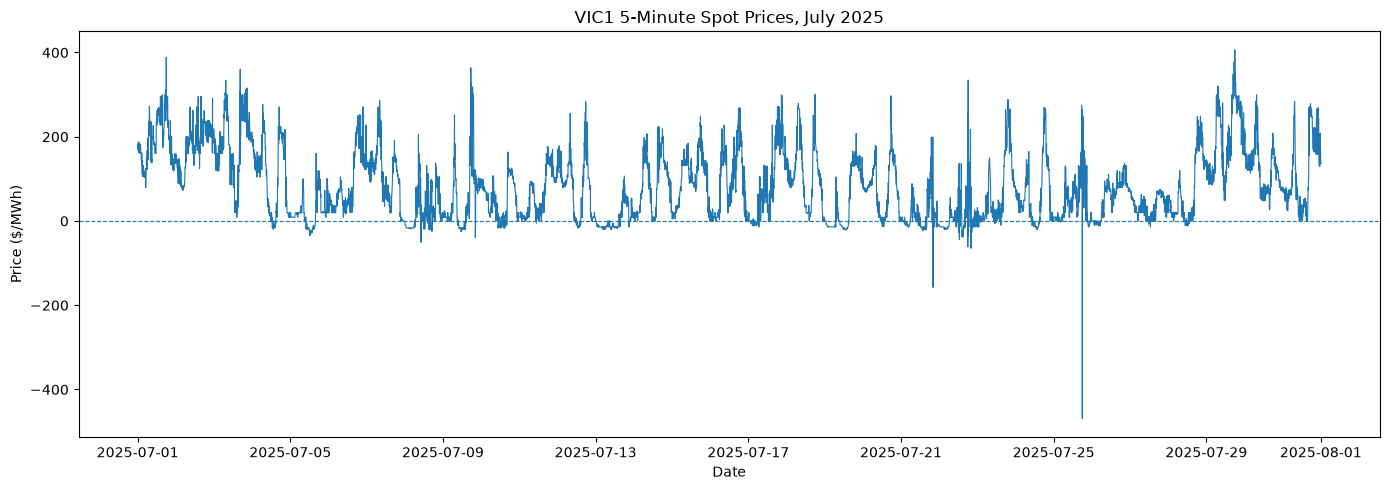

In [4]:
plt.figure(figsize=(14, 5))

plt.plot(
    milp["SETTLEMENTDATE"],
    milp["RRP"],
    linewidth=0.8
)

plt.axhline(
    0,
    linewidth=0.8,
    linestyle="--"
)

plt.title("VIC1 5-Minute Spot Prices, July 2025")
plt.xlabel("Date")
plt.ylabel("Price ($/MWh)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "july_spot_prices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [5]:
week = milp[
    (milp["SETTLEMENTDATE"] >= "2025-07-07")
    & (milp["SETTLEMENTDATE"] < "2025-07-14")
].copy()

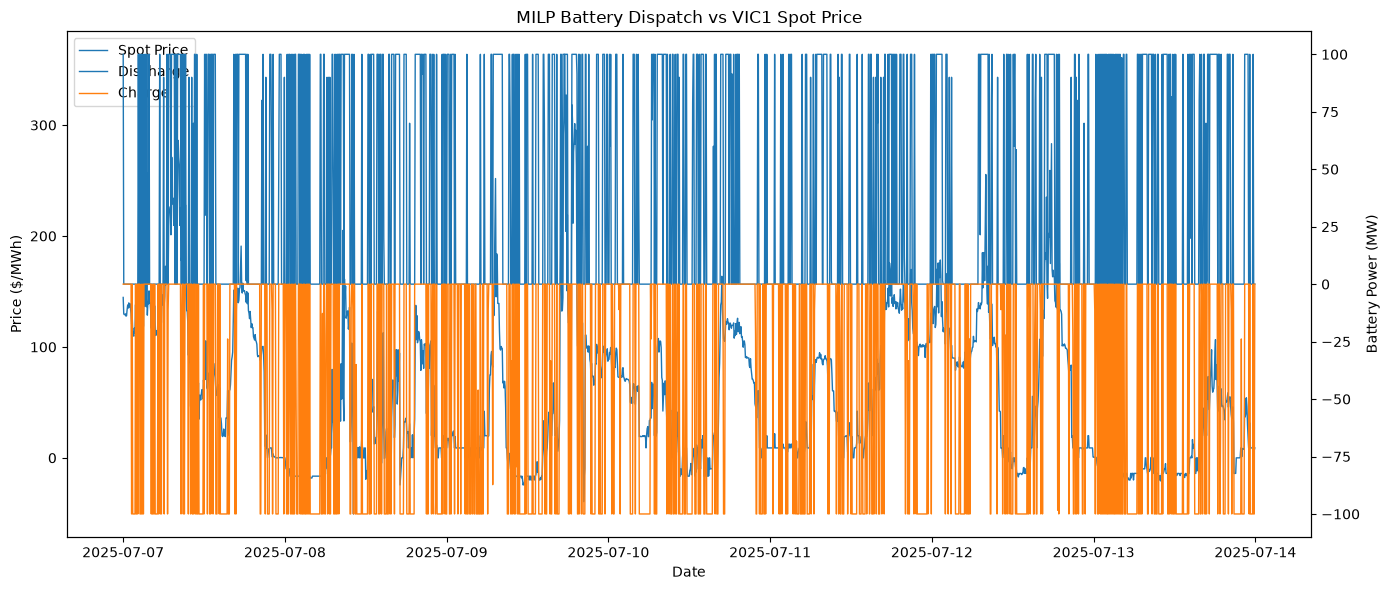

In [6]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    week["SETTLEMENTDATE"],
    week["RRP"],
    label="Spot Price",
    linewidth=1
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Price ($/MWh)")

ax2 = ax1.twinx()

ax2.plot(
    week["SETTLEMENTDATE"],
    week["discharge_mw"],
    label="Discharge",
    linewidth=1
)

ax2.plot(
    week["SETTLEMENTDATE"],
    -week["charge_mw"],
    label="Charge",
    linewidth=1
)

ax2.set_ylabel("Battery Power (MW)")

ax1.set_title(
    "MILP Battery Dispatch vs VIC1 Spot Price"
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "milp_dispatch_vs_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

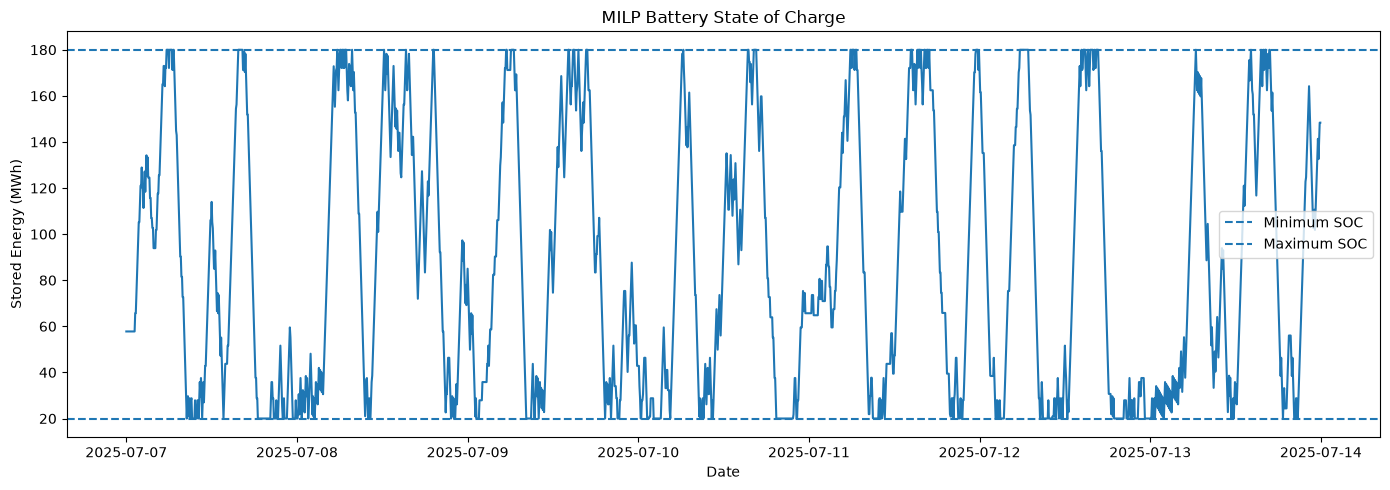

In [7]:
plt.figure(figsize=(14, 5))

plt.plot(
    week["SETTLEMENTDATE"],
    week["soc_mwh"],
    linewidth=1.5
)

plt.axhline(
    20,
    linestyle="--",
    label="Minimum SOC"
)

plt.axhline(
    180,
    linestyle="--",
    label="Maximum SOC"
)

plt.title("MILP Battery State of Charge")
plt.xlabel("Date")
plt.ylabel("Stored Energy (MWh)")

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "milp_soc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

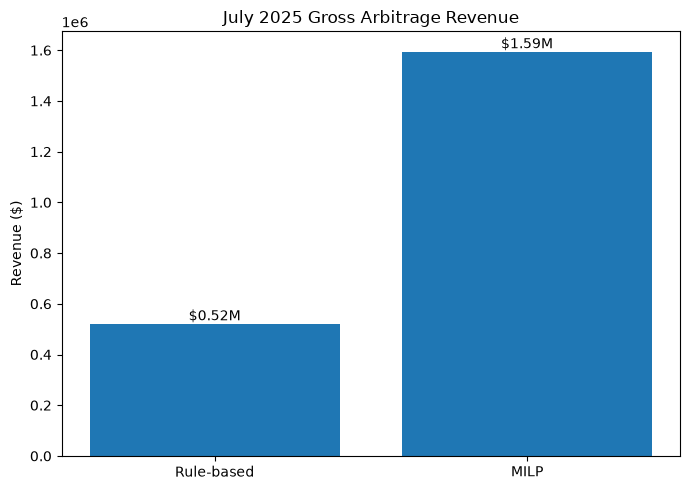

In [8]:
revenue_comparison = kpis[
    kpis["strategy"].isin(
        ["Rule-based", "MILP"]
    )
].copy()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    revenue_comparison["strategy"],
    revenue_comparison["revenue"]
)

plt.title("July 2025 Gross Arbitrage Revenue")
plt.ylabel("Revenue ($)")

for bar, value in zip(
    bars,
    revenue_comparison["revenue"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"${value / 1_000_000:.2f}M",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "revenue_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

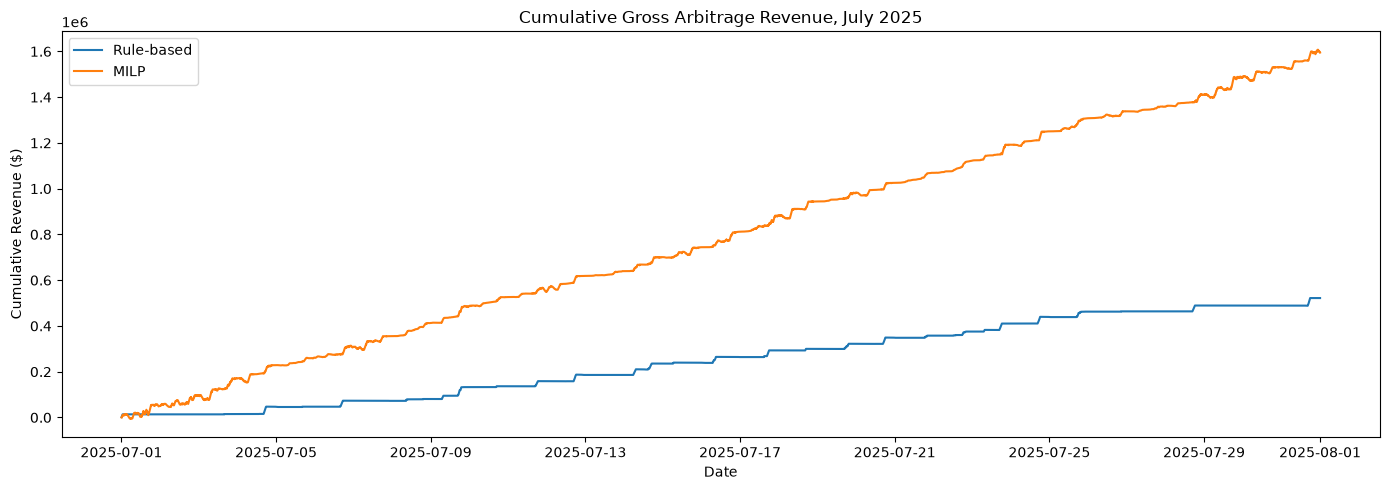

In [9]:
baseline["cumulative_revenue"] = (
    baseline["revenue"].cumsum()
)

milp["cumulative_revenue"] = (
    milp["revenue"].cumsum()
)

plt.figure(figsize=(14, 5))

plt.plot(
    baseline["SETTLEMENTDATE"],
    baseline["cumulative_revenue"],
    label="Rule-based"
)

plt.plot(
    milp["SETTLEMENTDATE"],
    milp["cumulative_revenue"],
    label="MILP"
)

plt.title("Cumulative Gross Arbitrage Revenue, July 2025")
plt.xlabel("Date")
plt.ylabel("Cumulative Revenue ($)")

plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "cumulative_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()